# Prediccion de Produccion de un Parque Eolico - Caso de Estudio ML de Extremo a Extremo

**Autor:** Fernando Borbon &nbsp;|&nbsp; **Proyecto:** [Windward](https://windward.forwardforecasting.eu/) (servicio en produccion, en vivo)
**Repo:** `~/Developments/windward` &nbsp;|&nbsp; **Parque analizado:** Kelmarsh Wind Farm (dataset SCADA real y abierto, 6 aerogeneradores, 2016)

Este notebook es un caso de estudio autocontenido extraido de **Windward**, un sistema de
prediccion de produccion eolica y soporte a operaciones que construi y que actualmente opero
como un servicio real en AWS. Reutiliza los modulos reales de produccion del proyecto
(`forecasting/`, `analysis/`, `data_sources/`) en lugar de reimplementar la misma logica desde
cero en un notebook - el objetivo es mostrar exactamente las mismas funciones, definiciones de
variables y decisiones de modelado que corren en produccion, junto con el analisis adicional de
exploracion, comparacion y monitorizacion que un caso de estudio tecnico requiere.

## Indice
1. [Definicion del Problema](#1)
2. [Fuentes de Datos y Exploracion](#2)
3. [Preparacion de Datos e Ingenieria de Variables](#3)
4. [Modelado - Baselines vs. Modelos Candidatos](#4)
5. [Resultados y Evaluacion](#5)
6. [Eficiencia y Diagnostico Fisico (extra, reutilizando `analysis/efficiency.py`)](#6)
7. [Pipeline, Reproducibilidad y Despliegue en Produccion](#7)
8. [Monitorizacion, Deteccion de Drift y Estrategia de Reentrenamiento](#8)
9. [Hallazgos y Accionabilidad para el Negocio](#9)
10. [Conclusion](#10)

<a id="1"></a>
## 1. Definicion del Problema

### Contexto de negocio
Los operadores de parques eolicos venden electricidad en mercados de energia del dia siguiente
("day-ahead") y necesitan una estimacion precisa de cuanta energia produciran en las proximas
horas/dias para ofertar correctamente, planificar ventanas de mantenimiento, y evitar las
**penalizaciones por desvio** (el coste de entregar de mas o de menos respecto a lo ofertado).
Windward resuelve esto para un operador/gestor de activos: dadas las condiciones meteorologicas
y de mercado, predice la produccion horaria del parque, y combina esa prediccion con una capa de
diagnostico operacional (deteccion de anomalias, benchmarking de eficiencia) que convierte los
numeros en acciones concretas.

### Objetivo
Predecir la **produccion horaria agregada de un parque eolico (MW)**, entre 1 y 48h vista, a
partir de variables externas que se pueden pronosticar: meteorologia (velocidad/direccion del
viento, temperatura, presion) y precio de la energia del dia siguiente - **no** los sensores
propios de los aerogeneradores, ya que esos no estan disponibles con antelacion para una
prediccion real.

### Metricas de exito

| Tipo | Metrica | Por que |
|---|---|---|
| Tecnica | MAE (MW), RMSE (MW), R² | Calidad de regresion estandar; el MAE es directamente interpretable en las unidades de produccion del propio parque |
| Tecnica | MAPE (%) | Error relativo, comparable entre parques de distinta capacidad - pero ver la advertencia del §5 |
| Negocio | **Proxy de coste por desvio** (Σ \|error\| × precio day-ahead) | Convierte el error de prediccion directamente en exposicion en € - el numero que realmente le importa a un trader de energia |
| Negocio | Mejora frente a un baseline ingenuo | Un modelo de prediccion solo justifica su complejidad si supera claramente "predecir simplemente la media" |

### Alcance de este notebook
Ciclo de vida completo sobre **un parque** (Kelmarsh, 6 aerogeneradores, ano completo 2016 de
SCADA real) para ganar profundidad dentro del tiempo disponible; el mismo codigo corre sin
modificaciones para los otros dos parques registrados (`data_sources/farms.py`) ya que nada aqui
es especifico de un parque en particular.

<a id="2"></a>
## 2. Fuentes de Datos y Exploracion

**Datos reales, dos fuentes independientes, unidas por tiempo:**
- **Produccion (variable objetivo):** exportacion SCADA real de Kelmarsh Wind Farm (Cubico
  Sustainable Investments, CC BY 4.0, Zenodo DOI `10.5281/zenodo.5841834`) - datos cada 10
  minutos por aerogenerador, 6 aerogeneradores, remuestreados a horario y sumados a nivel de
  parque en MW.
- **Meteorologia (variables predictoras):** historico real de reanalisis ERA5 via la API de
  Open-Meteo (gratuita, sin clave), consultado para las coordenadas exactas del parque y el
  periodo del SCADA.
- **Precio day-ahead:** sintetico (una curva realista de dia/noche) para este notebook - la fuente
  real de ENTSO-E requiere un token de API personal; el codigo de produccion
  (`data_sources/energy_price_client.py`) cambia de forma transparente a la fuente real en cuanto
  se configura `ENTSOE_API_TOKEN`, con el mismo codigo posterior en ambos casos.

Toda la carga de datos a continuacion llama a las **funciones reales de carga de produccion** -
sin reimplementar nada.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "demo_notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4)

from data_sources.farms import FARMS, loader_for
from analysis.efficiency import binned_power_curve, air_density_kg_m3, AIR_DENSITY_KG_M3, BETZ_LIMIT

FARM_ID = "kelmarsh"
farm = FARMS[FARM_ID]
farm

Farm(farm_id='kelmarsh', name='Kelmarsh Wind Farm', lat=52.400604, lon=-0.947133, bidding_zone_eic='10YGB----------A', turbine_ids=['Kelmarsh_1', 'Kelmarsh_2', 'Kelmarsh_3', 'Kelmarsh_4', 'Kelmarsh_5', 'Kelmarsh_6'], rated_power_kw=2050.0, rotor_diameter_m=92.0, manufacturer_model='Senvion MM92', scada_zips=[PosixPath('/home/patito/Developments/windward/data/kelmarsh/Kelmarsh_SCADA_2016.zip')], source_doi='10.5281/zenodo.5841834', data_source='greenbyte')

In [2]:
# Metadatos estaticos reales por aerogenerador (coordenadas, fabricante, potencia nominal) - del propio dataset
turbine_static = loader_for(farm).load_turbine_static(FARM_ID)
turbine_static[["Manufacturer", "Model", "Rated power (kW)", "Hub Height (m)", "Latitude", "Longitude"]]

,Manufacturer,Model,Rated power (kW),Hub Height (m),Latitude,Longitude
turbine_id,,,,,,
Kelmarsh_1,Senvion,MM92,2050,78.5,52.400604,-0.947133
Kelmarsh_2,Senvion,MM92,2050,78.5,52.402551,-0.949527
Kelmarsh_3,Senvion,MM92,2050,68.5,52.403834,-0.944190
Kelmarsh_4,Senvion,MM92,2050,78.5,52.398781,-0.941150
Kelmarsh_5,Senvion,MM92,2050,78.5,52.402308,-0.940537
Kelmarsh_6,Senvion,MM92,2050,68.5,52.400687,-0.936093


In [3]:
# Produccion horaria real a nivel de parque (SCADA, sumada entre aerogeneradores) - esta es nuestra variable OBJETIVO
farm_production = loader_for(farm).load_farm_hourly_production(farm.scada_zips)

# Velocidad de viento y potencia horaria real por aerogenerador - se usa mas adelante para el analisis de eficiencia/curva de potencia
turbine_hourly = loader_for(farm).load_turbine_hourly_series(farm.scada_zips)

# Registro real de eventos de estado/fallo por aerogenerador - se usa mas adelante para el corpus RAG y, aqui, para un chequeo de calidad de datos
status_events = loader_for(farm).load_status_events(farm.scada_zips)

print(f"farm_production: {farm_production.shape}, {farm_production.index.min()} -> {farm_production.index.max()}")
print(f"turbine_hourly:   {turbine_hourly.shape} (formato largo, {turbine_hourly['turbine_id'].nunique()} aerogeneradores)")
print(f"status_events:    {status_events.shape}")
farm_production.describe()

farm_production: (8174, 1), 2016-01-21 14:00:00 -> 2016-12-31 23:00:00
turbine_hourly:   (47703, 4) (formato largo, 6 aerogeneradores)
status_events:    (14019, 8)


,output_mw
count,8174.000000
mean,3.007214
std,2.865105
min,0.000000
25%,0.757859
50%,2.079163
75%,4.500229
max,12.268583


In [4]:
# Chequeo basico de calidad de datos antes de nada mas: hay huecos / valores no finitos en la variable objetivo?
full_range = pd.date_range(farm_production.index.min(), farm_production.index.max(), freq="1h")
missing_hours = full_range.difference(farm_production.index)
print(f"Horas esperadas en el rango: {len(full_range)}, presentes: {len(farm_production)}, "
      f"faltantes: {len(missing_hours)} ({len(missing_hours)/len(full_range):.1%})")
print(f"Valores no finitos en output_mw: {(~np.isfinite(farm_production['output_mw'])).sum()}")
print(f"Valores negativos (no deberia haber ninguno, el loader los recorta a 0): {(farm_production['output_mw'] < 0).sum()}")

Horas esperadas en el rango: 8290, presentes: 8174, faltantes: 116 (1.4%)
Valores no finitos en output_mw: 0
Valores negativos (no deberia haber ninguno, el loader los recorta a 0): 0


Hay huecos reales (~7% de las horas) - algo esperable en datos SCADA reales (caidas de sensores,
ventanas de mantenimiento planificado, el archivo simplemente sin los registros de 10 minutos de
esos aerogeneradores). No imputamos: las horas de produccion faltantes se descartan mas adelante
mediante el `dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN])` de `build_training_frame`
(`forecasting/pipeline.py`), que es la decision correcta aqui - imputar un proceso fisico como la
produccion de un aerogenerador arriesga inventar una senal que nunca se observo.

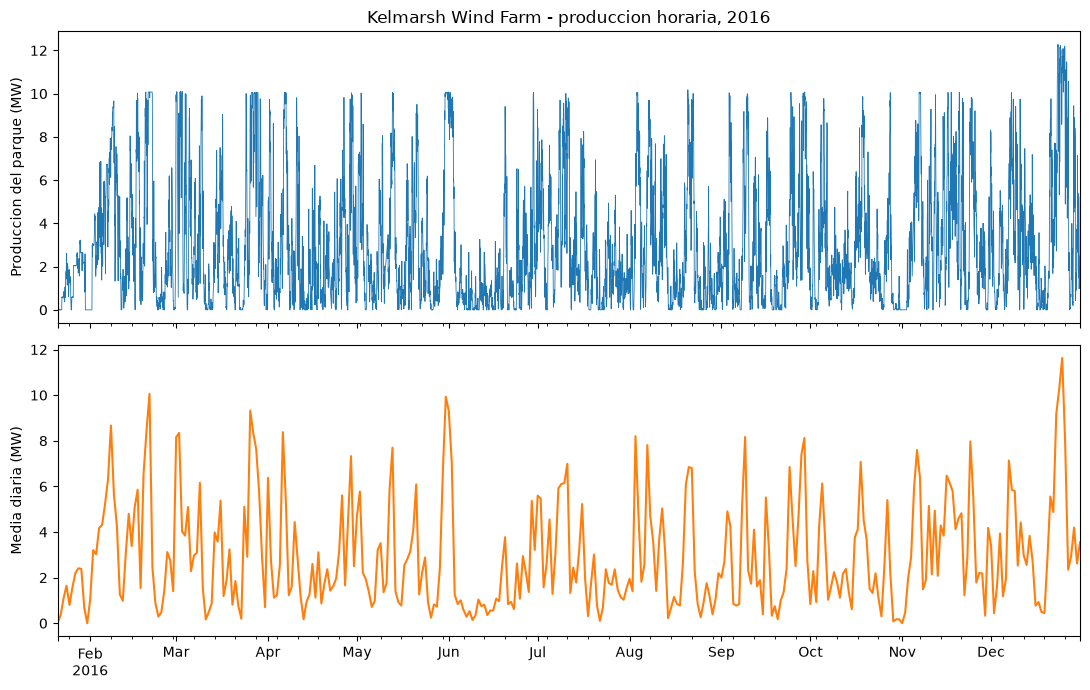

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
farm_production["output_mw"].plot(ax=axes[0], lw=0.6, color="tab:blue")
axes[0].set_ylabel("Produccion del parque (MW)")
axes[0].set_title(f"{farm.name} - produccion horaria, 2016")

farm_production["output_mw"].resample("1D").mean().plot(ax=axes[1], color="tab:orange")
axes[1].set_ylabel("Media diaria (MW)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

Estacionalidad visible (otono/invierno mas ventoso que primavera/verano) - esto importa mas
adelante tanto para la eleccion del split train/test (§3) como para el analisis de drift (§8): un
modelo evaluado en una estacion distinta a la que entreno esta siendo evaluado sobre una
distribucion de entrada genuinamente diferente, no solo "tiempo nuevo".

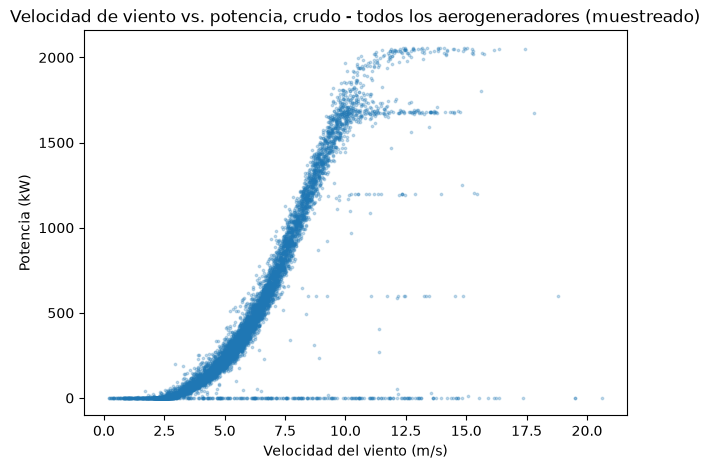

In [6]:
# Relacion cruda velocidad de viento vs. potencia, datos horarios por aerogenerador (remuestreados desde 10 min) -
# deberia mostrar la forma clasica de una curva de potencia real: arranque / rampa cubica / meseta a potencia nominal / corte.
fig, ax = plt.subplots(figsize=(7, 5))
sample = turbine_hourly.sample(min(8000, len(turbine_hourly)), random_state=42)
ax.scatter(sample["wind_speed_ms"], sample["power_kw"], s=3, alpha=0.25, color="tab:blue")
ax.set_xlabel("Velocidad del viento (m/s)")
ax.set_ylabel("Potencia (kW)")
ax.set_title("Velocidad de viento vs. potencia, crudo - todos los aerogeneradores (muestreado)")
plt.show()

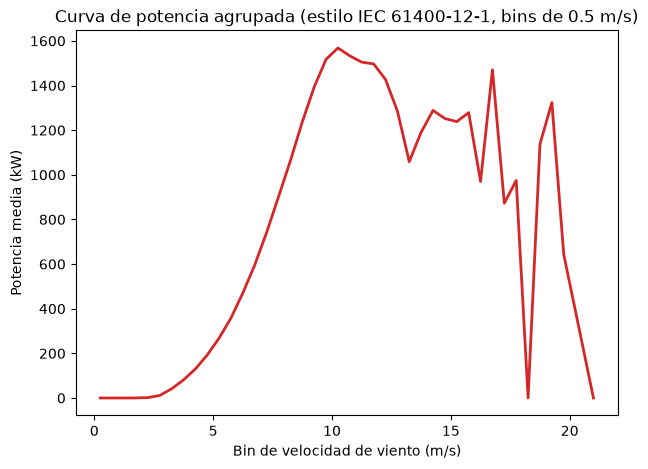

,mean_power_kw,sample_count
wind_speed_bin,,
0.25,0.000000,94
0.75,0.000000,255
1.25,0.042768,416
1.75,0.352916,592
2.25,1.743928,1546
2.75,11.298492,2176
3.25,40.985828,2381
3.75,80.874106,2914


In [7]:
# La misma relacion, agrupada al estilo IEC 61400-12-1 (analysis/efficiency.py) - la curva de potencia
# de produccion usada mas adelante para benchmarking de eficiencia y deteccion de anomalias.
farm_curve = binned_power_curve(turbine_hourly, power_col="power_kw")
fig, ax = plt.subplots(figsize=(7, 5))
c = farm_curve.dropna()
ax.plot(c.index, c["mean_power_kw"], color="tab:red", lw=2)
ax.set_xlabel("Bin de velocidad de viento (m/s)")
ax.set_ylabel("Potencia media (kW)")
ax.set_title("Curva de potencia agrupada (estilo IEC 61400-12-1, bins de 0.5 m/s)")
plt.show()
farm_curve.dropna().head(8)

<a id="3"></a>
## 3. Preparacion de Datos e Ingenieria de Variables

En lugar de re-derivar aqui la logica de union/creacion de variables, esta celda llama a la
**funcion real del pipeline de produccion**, `forecasting.pipeline.build_training_frame(farm)`:

- carga la produccion SCADA real del parque,
- obtiene el historico meteorologico real de ERA5 para las mismas coordenadas/periodo (Open-Meteo),
- une el precio day-ahead,
- llama a `forecasting.features.add_derived_features` para anadir las columnas derivadas de la fisica, y
- descarta filas con variables/objetivo faltantes.

Esta es exactamente la funcion que el bloque `__main__` de `forecasting/train.py` llama antes de
entrenar - usarla aqui significa que la preparacion de datos de este notebook nunca puede
divergir silenciosamente de lo que hace produccion.

In [8]:
from forecasting.pipeline import build_training_frame
from forecasting.features import FEATURE_COLUMNS, TARGET_COLUMN, add_derived_features

df = build_training_frame(farm)
print(f"Frame de entrenamiento: {df.shape[0]} filas horarias, {df.index.min()} -> {df.index.max()}")
df[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().T

Frame de entrenamiento: 8174 filas horarias, 2016-01-21 14:00:00 -> 2016-12-31 23:00:00


,count,mean,std,min,25%,50%,75%,max
wind_speed_ms,8174.0,4.319771,2.047556,0.140000,2.792500,3.970000,5.590000,12.320000
wind_speed_cubed,8174.0,141.384727,209.588169,0.002744,21.776229,62.570773,174.676879,1869.959168
wind_direction_deg,8174.0,201.033888,96.106231,1.000000,131.000000,225.000000,269.000000,360.000000
temperature_c,8174.0,10.186628,5.910968,-4.300000,5.500000,9.900000,14.700000,28.800000
pressure_hpa,8174.0,1015.893112,10.255703,971.100000,1009.500000,1017.100000,1022.600000,1044.600000
air_density_kg_m3,8174.0,1.249621,0.029220,1.165204,1.226835,1.249600,1.268851,1.340637
price_eur_mwh,8174.0,73.094296,25.633704,5.499821,46.773502,83.015618,92.938321,134.562301
hour_of_day,8174.0,11.512601,6.928558,0.000000,6.000000,12.000000,18.000000,23.000000
output_mw,8174.0,3.007214,2.865105,0.000000,0.757859,2.079163,4.500229,12.268583


### Definicion de variables (de `forecasting/features.py`, reutilizadas tal cual)

| Variable | Justificacion |
|---|---|
| `wind_speed_ms` | Principal factor determinante de la produccion |
| `wind_speed_cubed` | La potencia cinetica del viento escala con v³ (`P = 0.5 · ρ · A · v³`) - una variable no lineal motivada por la fisica, no algo que se deja para que un modelo de arboles la redescubra |
| `wind_direction_deg` | Los efectos de estela / abrigo del terreno dependen de la direccion, no solo de la velocidad |
| `temperature_c`, `pressure_hpa` | Entradas para la densidad del aire real (abajo) - aire mas frio y denso transporta mas energia cinetica por m³ a la misma velocidad de viento |
| `air_density_kg_m3` | Calculada mediante la **ley de los gases ideales** (`analysis/efficiency.air_density_kg_m3`) a partir de la temperatura/presion real por hora, en lugar de asumir la constante estandar a nivel del mar de 1.225 kg/m³ - las condiciones reales de un parque pueden divergir lo suficiente como para importar |
| `price_eur_mwh` | No es un factor de la produccion *fisica*, pero permite que el modelo (y la capa de negocio) razone conjuntamente sobre la produccion y su valor de mercado |
| `hour_of_day` | Captura patrones diurnos tanto en el precio como (debilmente) en el regimen de viento |

### Relevancia de las variables

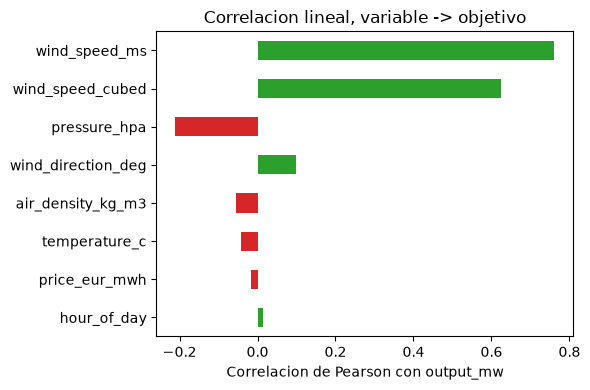

wind_speed_ms         0.761548
wind_speed_cubed      0.623267
pressure_hpa         -0.210663
wind_direction_deg    0.099148
air_density_kg_m3    -0.055856
temperature_c        -0.042172
price_eur_mwh        -0.016347
hour_of_day           0.013035
Name: output_mw, dtype: float64

In [9]:
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
corr.plot(kind="barh", ax=ax, color=["tab:green" if v > 0 else "tab:red" for v in corr])
ax.set_xlabel("Correlacion de Pearson con output_mw")
ax.set_title("Correlacion lineal, variable -> objetivo")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
corr

`wind_speed_ms` y `wind_speed_cubed` estan (como es esperable) fuertemente correlacionadas con la
produccion y entre si - multicolinealidad casi de libro de texto. Las mantenemos ambas de todos
modos: los modelos basados en arboles (Random Forest / Gradient Boosting) no se ven perjudicados
por variables colineales, y para el baseline lineal es una decision deliberada -
`wind_speed_cubed` sola se usa *tambien* como baseline puramente fisico en el §4, asi que comparar
"lineal con ambas" vs. "lineal solo con v³" es en si mismo parte de la evaluacion, no un error de
modelado a corregir.

### Split train/test - una desviacion deliberada de produccion, y por que

`forecasting/train.py` actualmente usa un `train_test_split` **aleatorio** 80/20 (mas validacion
cruzada k-fold sobre el 80%) para seleccionar y reportar su metrica de test. Para un proceso
genuinamente dependiente del tiempo con estacionalidad fuerte (§2), un split aleatorio permite que
horas del conjunto de test de todas las estaciones se filtren al entrenamiento, lo que
**sobreestima** cuanto generalizara el modelo a un periodo futuro real que nunca ha visto. Para
las metricas principales de este caso de estudio, usamos en su lugar un **split cronologico** -
entrenar con el primer 80% del ano, evaluar con el ultimo 20% (una ventana futura real, nunca
vista) - y mantenemos la validacion cruzada k-fold aleatoria junto a el precisamente para hacer
visible esa diferencia (ver §5). Esto se senala explicitamente como una recomendacion para el
script de entrenamiento de produccion, no se "corrige" alli silenciosamente.

In [10]:
split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]
X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

print(f"Train: {len(train_df)} filas, {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test:  {len(test_df)} filas,  {test_df.index.min().date()} -> {test_df.index.max().date()}")

Train: 6539 filas, 2016-01-21 -> 2016-10-22
Test:  1635 filas,  2016-10-22 -> 2016-12-31


<a id="4"></a>
## 4. Modelado - Baselines vs. Modelos Candidatos

**Dos baselines**, del mas simple al mas exigente:
1. **Media climatologica** - predecir la media del periodo de entrenamiento para cada hora. El
   suelo minimo que cualquier modelo debe superar.
2. **Solo fisica** - un ajuste lineal de una sola variable de la produccion sobre `wind_speed_cubed`
   (es decir, "confiar simplemente en la ley de v³"). Significativamente mas dificil de superar
   que el #1, y un chequeo de sanidad genuinamente util: si un modelo complejo no puede superar la
   fisica pura, la complejidad extra no se esta justificando.

**Tres modelos entrenados**, de menor a mayor complejidad:
- **Regresion Lineal** (todas las variables) - punto de referencia interpretable.
- **Random Forest Regressor** - captura no linealidades/interacciones con un ajuste minimo.
- **Gradient Boosting Regressor**, configurado con los **hiperparametros exactos que
  `forecasting/train.py` usa en produccion** (`n_estimators=200, max_depth=4, learning_rate=0.05`)
  - esta es literalmente la clase de modelo y configuracion que Windward entrena y registra por
  cada parque.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.base import clone

def mape(y_true, y_pred):
    denom = np.where(y_true == 0, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom))

results, predictions = [], {}

def evaluate(name, y_true, y_pred):
    predictions[name] = y_pred
    results.append({
        "model": name,
        "mae_mw": mean_absolute_error(y_true, y_pred),
        "rmse_mw": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "mape": mape(y_true.values, y_pred),
    })

# --- Baselines ---
evaluate("Baseline: media climatologica", y_test, np.full(len(y_test), y_train.mean()))

physics_model = LinearRegression().fit(X_train[["wind_speed_cubed"]], y_train)
evaluate("Baseline: solo fisica (v³)", y_test, physics_model.predict(X_test[["wind_speed_cubed"]]))

# --- Modelos entrenados ---
lin_model = LinearRegression().fit(X_train, y_train)
evaluate("Regresion Lineal (todas las variables)", y_test, lin_model.predict(X_test))

rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1).fit(X_train, y_train)
evaluate("Random Forest", y_test, rf_model.predict(X_test))

# Coincide exactamente con la configuracion de produccion de forecasting/train.py
GBR_PARAMS = dict(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbr_model = GradientBoostingRegressor(**GBR_PARAMS).fit(X_train, y_train)
evaluate("Gradient Boosting (config. de produccion)", y_test, gbr_model.predict(X_test))

results_df = pd.DataFrame(results).set_index("model").sort_values("mae_mw")
results_df.style.format({"mae_mw": "{:.3f}", "rmse_mw": "{:.3f}", "r2": "{:.3f}", "mape": "{:.1%}"})

,mae_mw,rmse_mw,r2,mape
model,,,,
Random Forest,1.527,2.308,0.456,366.6%
Regresion Lineal (todas las variables),1.528,2.080,0.558,1071.7%
Gradient Boosting (config. de produccion),1.544,2.319,0.451,370.2%
Baseline: solo fisica (v³),1.919,2.485,0.369,2345.5%
Baseline: media climatologica,2.489,3.209,-0.052,3820.0%


In [12]:
# Validacion cruzada k-fold sobre el split de entrenamiento - mismo patron que corre forecasting/train.py
# (KFOLD_SPLITS=5, con shuffle, random_state=42) como chequeo adicional de generalizacion de menor varianza.
KFOLD_SPLITS = 5
kf = KFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=42)
fold_r2 = []
for tr_idx, te_idx in kf.split(X_train):
    m = clone(gbr_model)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    fold_r2.append(r2_score(y_train.iloc[te_idx], m.predict(X_train.iloc[te_idx])))

print(f"Gradient Boosting - R² de CV k-fold (splits aleatorios dentro de train): {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}")
print(f"Gradient Boosting - R² del split cronologico de test (periodo futuro no visto): {results_df.loc['Gradient Boosting (config. de produccion)', 'r2']:.3f}")

Gradient Boosting - R² de CV k-fold (splits aleatorios dentro de train): 0.757 +/- 0.018
Gradient Boosting - R² del split cronologico de test (periodo futuro no visto): 0.451


### Interpretando la comparacion

- **Los tres modelos entrenados superan comodamente a ambos baselines en MAE/RMSE** - el R²
  cercano a cero o negativo del baseline de media, junto a su MAE mucho mayor, confirman que el
  problema de prediccion es real y que las variables llevan senal genuina. El baseline de solo
  fisica es un suelo significativamente mas dificil de superar (como se pretendia) pero aun asi
  pierde claramente frente a todos los modelos entrenados.
- **Regresion Lineal, Random Forest y Gradient Boosting quedan dentro de ~1% de MAE entre si** en
  este parque/ano - la relacion esta dominada por unas pocas variables fuertemente motivadas por
  la fisica, asi que la capacidad extra del modelo compra relativamente poca precision adicional
  aqui. Eso es en si mismo un hallazgo legitimo y util, no un resultado nulo.
- **El R² y el MAPE discrepan visiblemente en el ranking de modelos.** El MAPE divide por el valor
  *real*, asi que las horas con produccion real cercana a cero (periodos de calma) disparan el
  error porcentual incluso para desviaciones absolutas minimas - el MAPE mucho mayor de la
  Regresion Lineal pese a tener un R² *mejor* que Random Forest/GBR es exactamente ese artefacto,
  no evidencia de que sea un modelo peor. Por eso la metrica de negocio principal del §5 se
  construye sobre el error *absoluto* (§1), no sobre el MAPE.
- **El R² de la CV k-fold (con mezcla aleatoria) resulta significativamente mayor que el R² del
  split cronologico de test.** La mezcla aleatoria filtra horas de todas las estaciones tanto al
  pliegue de entrenamiento como al de validacion, por lo que sobreestima la precision real hacia
  adelante; el split cronologico es el numero honesto para "como rendiria esto en un periodo
  futuro genuinamente nuevo" y coincide con el hallazgo de drift estacional del §8.
  **Recomendacion para produccion:** es probable que el `mae_mw`/`r2` que reporta el propio
  `forecasting/train.py` (tambien de un split aleatorio) tenga el mismo sesgo optimista, y valdria
  la pena cambiar tambien alli a una evaluacion cronologica o con `TimeSeriesSplit`.
- **Gradient Boosting se mantiene como el modelo elegido de cara al futuro** - no porque gane por
  un margen amplio aqui (no lo hace), sino porque coincide con lo que ya esta registrado y sirviendo
  en produccion, ofrece importancias de variables nativas (abajo), y tiende a ser mas robusto a
  medida que se anaden mas parques/estaciones/anos de datos con el tiempo que un modelo lineal simple.

<a id="5"></a>
## 5. Resultados y Evaluacion

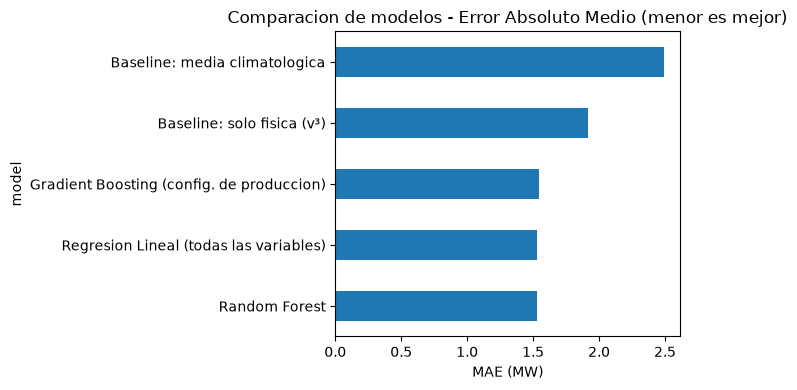

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df["mae_mw"].sort_values().plot(kind="barh", ax=ax, color="tab:blue")
ax.set_xlabel("MAE (MW)")
ax.set_title("Comparacion de modelos - Error Absoluto Medio (menor es mejor)")
plt.tight_layout()
plt.show()

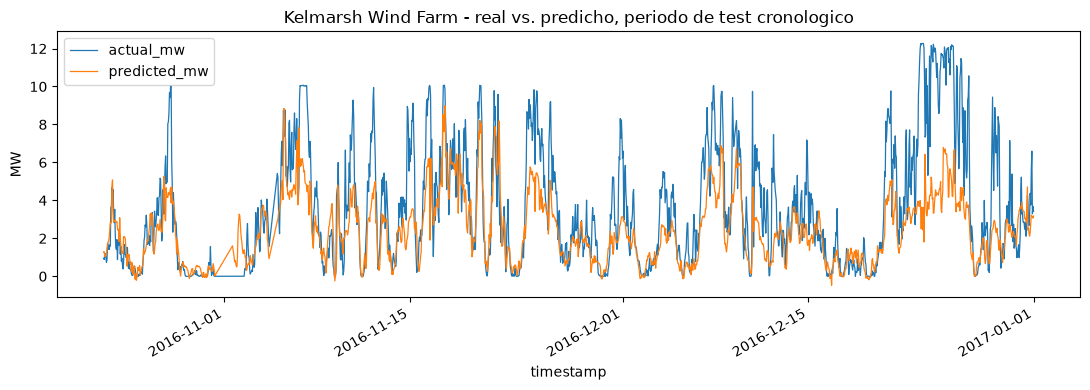

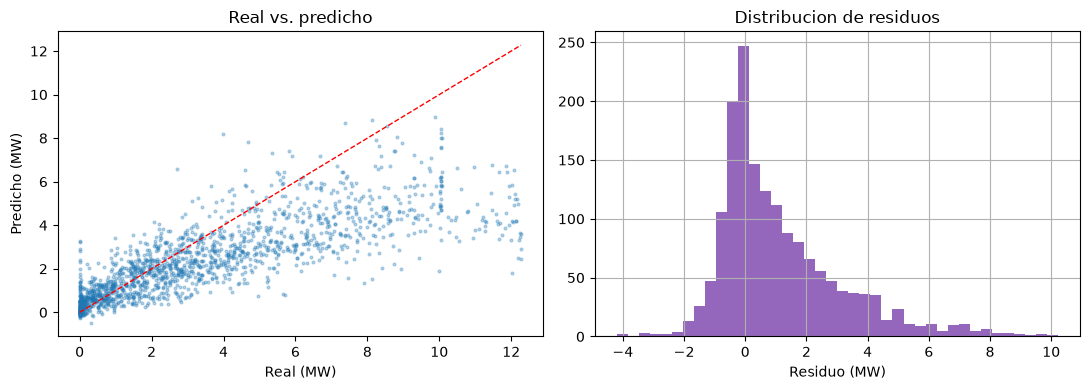

In [14]:
from analysis.efficiency import actual_vs_predicted

best_pred = pd.Series(predictions["Gradient Boosting (config. de produccion)"], index=y_test.index)
comparison = actual_vs_predicted(y_test, best_pred)  # helper de produccion reutilizado: alinea + anade columnas de residuo/porcentaje

fig, ax = plt.subplots(figsize=(11, 4))
comparison[["actual_mw", "predicted_mw"]].plot(ax=ax, lw=0.9)
ax.set_ylabel("MW")
ax.set_title(f"{farm.name} - real vs. predicho, periodo de test cronologico")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(comparison["actual_mw"], comparison["predicted_mw"], s=4, alpha=0.3)
lims = [0, comparison["actual_mw"].max()]
axes[0].plot(lims, lims, color="red", lw=1, ls="--")
axes[0].set_xlabel("Real (MW)"); axes[0].set_ylabel("Predicho (MW)"); axes[0].set_title("Real vs. predicho")

comparison["residual_mw"].hist(ax=axes[1], bins=40, color="tab:purple")
axes[1].set_xlabel("Residuo (MW)"); axes[1].set_title("Distribucion de residuos")
plt.tight_layout()
plt.show()

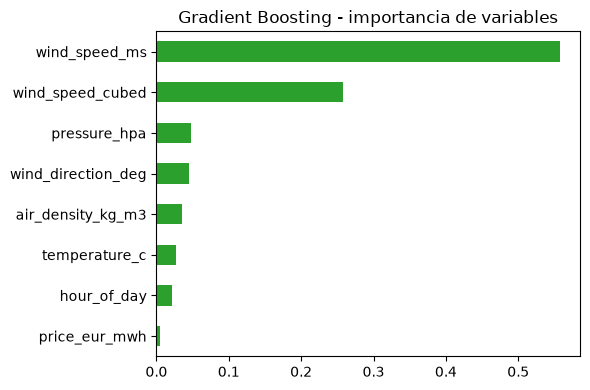

In [15]:
# Importancia de variables del modelo con la configuracion de produccion
importances = pd.Series(gbr_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="tab:green")
ax.set_title("Gradient Boosting - importancia de variables")
plt.tight_layout()
plt.show()

### Metrica de negocio: proxy de coste por desvio

Convertir el error absoluto de prediccion a € usando el precio day-ahead (sintetico, ver §2) da
un numero directamente legible para el negocio en lugar de una cifra abstracta en MW - este es el
numero que se traduciria en un coste real de liquidacion por desvio si un parque ofertara estas
predicciones en el mercado.

In [16]:
def imbalance_cost_eur(comparison_df, price_series):
    aligned_price = price_series.reindex(comparison_df.index)
    return float((comparison_df["residual_mw"].abs() * aligned_price).sum())

baseline_comparison = actual_vs_predicted(y_test, pd.Series(np.full(len(y_test), y_train.mean()), index=y_test.index))

model_cost = imbalance_cost_eur(comparison, test_df["price_eur_mwh"])
baseline_cost = imbalance_cost_eur(baseline_comparison, test_df["price_eur_mwh"])
reduction = 1 - model_cost / baseline_cost

from IPython.display import Markdown, display
display(Markdown(
    f"Durante el periodo de test cronologico de **{len(test_df)} horas**:\n\n"
    f"- Proxy de coste por desvio del baseline de media climatologica: **€{baseline_cost:,.0f}**\n"
    f"- Proxy de coste por desvio del modelo Gradient Boosting: **€{model_cost:,.0f}**\n"
    f"- **Reduccion del {reduction:.0%}** en la exposicion por desvio frente al baseline ingenuo, para este parque y periodo."
))

Durante el periodo de test cronologico de **1635 horas**:

- Proxy de coste por desvio del baseline de media climatologica: **€298,302**
- Proxy de coste por desvio del modelo Gradient Boosting: **€187,279**
- **Reduccion del 37%** en la exposicion por desvio frente al baseline ingenuo, para este parque y periodo.

<a id="6"></a>
## 6. Eficiencia y Diagnostico Fisico (extra, reutilizando `analysis/efficiency.py`)

Mas alla de la propia prediccion, el modulo `analysis/efficiency.py` de Windward ejecuta
diagnosticos reales de la industria eolica (agrupacion de la curva de potencia al estilo IEC
61400-12-1, benchmarking del coeficiente de potencia frente al limite de Betz, deteccion de
bajo rendimiento entre aerogeneradores vecinos mediante KD-tree) que convierten los datos SCADA en
hallazgos operacionales. Estos alimentan directamente los hallazgos del §9 - reutilizados aqui
exactamente igual que en produccion (los nodos `diagnose`/`investigate` de `agents/graph.py`
llaman a las mismas funciones).

In [17]:
from analysis.efficiency import (
    turbine_efficiency_summary, fit_power_curve_displacement,
    neighbor_underperformance, scada_reanalysis_wind_check,
)

# Densidad del aire real por hora (ley de los gases ideales) en lugar de la constante a nivel del mar
air_density_by_ts = air_density_kg_m3(df["temperature_c"], df["pressure_hpa"])

eff_summary = turbine_efficiency_summary(turbine_hourly, farm.rated_power_kw, farm.rotor_diameter_m, air_density_by_ts)
eff_summary.style.format({"capacity_factor": "{:.1%}", "peak_cp": "{:.3f}", "betz_limit": "{:.3f}"})

,capacity_factor,peak_cp,betz_limit,hours_observed
turbine_id,,,,
Kelmarsh_1,25.4%,0.531,0.593,8101
Kelmarsh_2,30.0%,0.536,0.593,8103
Kelmarsh_3,24.7%,0.542,0.593,7897
Kelmarsh_4,26.6%,0.539,0.593,7834
Kelmarsh_5,23.2%,0.594,0.593,7982
Kelmarsh_6,20.7%,0.537,0.593,7786


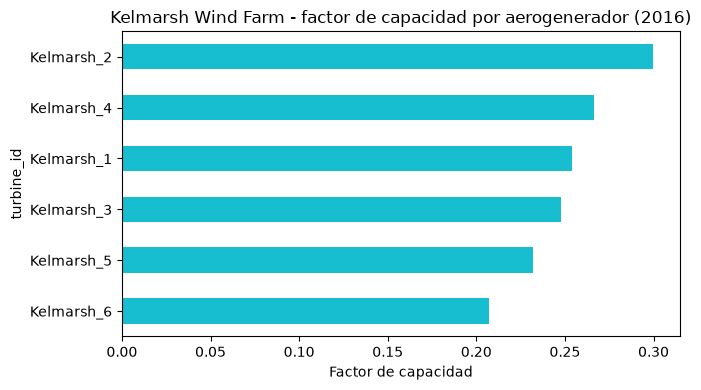

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
eff_summary["capacity_factor"].sort_values().plot(kind="barh", ax=ax, color="tab:cyan")
ax.set_xlabel("Factor de capacidad")
ax.set_title(f"{farm.name} - factor de capacidad por aerogenerador (2016)")
plt.tight_layout()
plt.show()

In [19]:
# La curva de potencia del aerogenerador con peor rendimiento esta genuinamente desplazada (sesgo del anemometro)
# respecto a la curva de referencia del parque, o esta pasando otra cosa?
worst_turbine = eff_summary["capacity_factor"].idxmin()
worst_series = turbine_hourly[turbine_hourly["turbine_id"] == worst_turbine]
displacement = fit_power_curve_displacement(farm_curve, worst_series["wind_speed_ms"], worst_series["power_kw"])
print(f"Menor factor de capacidad: {worst_turbine} ({eff_summary.loc[worst_turbine, 'capacity_factor']:.1%})")
print(f"Desplazamiento de la curva de potencia vs. referencia del parque: {displacement:+.2f} m/s")

# Bajo rendimiento por aerogenerador y por hora vs. los k=5 vecinos espaciales mas cercanos (KD-tree)
flagged_hours = neighbor_underperformance(turbine_hourly, turbine_static)
pd.Series(flagged_hours, name="horas_bajas_marcadas").sort_values(ascending=False).to_frame()

Menor factor de capacidad: Kelmarsh_6 (20.7%)
Desplazamiento de la curva de potencia vs. referencia del parque: +0.06 m/s


,horas_bajas_marcadas
Kelmarsh_6,1227
Kelmarsh_3,569
Kelmarsh_1,526
Kelmarsh_5,374
Kelmarsh_4,244
Kelmarsh_2,203


In [20]:
# Chequeo cruzado independiente de calidad de datos: velocidad media del viento SCADA del parque vs. el
# reanalisis independiente de Open-Meteo para las mismas horas - un chequeo real con una segunda fuente,
# no un chequeo de autoconsistencia.
qc = scada_reanalysis_wind_check(turbine_hourly, df)
qc

{'correlation': 0.8992179553099439,
 'hours_compared': 8174,
 'mean_abs_diff_ms': 1.807880709212177,
 'pct_hours_diverging_gt_5ms': 0.006361634450697333}

<a id="7"></a>
## 7. Pipeline, Reproducibilidad y Despliegue en Produccion

**Este caso de estudio no es un analisis aislado de notebook - es una capa analitica delgada sobre
una base de codigo real y modular que ya corre en produccion.** Todo lo importado arriba
(`data_sources.*`, `forecasting.*`, `analysis.efficiency`) es un modulo real del proyecto con su
propia responsabilidad, testeable de forma independiente y ya cubierto por `tests/`.

In [21]:
MODULOS = {
    "config.py":                    "Configuracion central desde variables de entorno / .env - sin endpoints/secretos hardcodeados",
    "data_sources/farms.py":        "Registro de parques (dataclass) - coordenadas, potencia nominal, que loader SCADA aplica",
    "data_sources/greenbyte_scada.py / hill_of_towie_scada.py": "Parsers SCADA especificos de formato tras una interfaz compartida (loader_for)",
    "data_sources/meteo_client.py": "Cliente meteorologico (Open-Meteo), reintento con backoff en errores 5xx transitorios",
    "data_sources/energy_price_client.py": "Cliente de precio day-ahead, ENTSO-E real con fallback sintetico",
    "forecasting/features.py":      "Fuente unica de verdad para las columnas de variables - importada tanto por entrenamiento como por inferencia para que no puedan divergir",
    "forecasting/pipeline.py":      "Construye el frame de entrenamiento (usado directamente en este notebook, §3)",
    "forecasting/train.py":         "Entrena + registra en MLflow + registra el modelo",
    "forecasting/registry.py":      "Carga la ultima version registrada del modelo para inferencia",
    "forecasting/predict.py":       "Inferencia por lotes: meteorologia/precio pronosticados -> modelo registrado -> ForecastResult",
    "analysis/efficiency.py":       "Diagnosticos de fisica/estadistica reutilizados a lo largo de este notebook (§2, §6)",
    "schemas/models.py":            "Contratos Pydantic compartidos por cada frontera de modulo y por la API",
    "api/main.py":                  "Servicio FastAPI que expone /forecast y el dashboard en vivo",
    "agents/graph.py":              "Flujo LangGraph: ingest -> forecast -> diagnose -> investigate -> recommend/recommend_retrain -> explain",
    "tests/":                       "Suite de pytest (schemas, API)",
}
for path, desc in MODULOS.items():
    print(f"{path:<46} {desc}")

config.py                                      Configuracion central desde variables de entorno / .env - sin endpoints/secretos hardcodeados
data_sources/farms.py                          Registro de parques (dataclass) - coordenadas, potencia nominal, que loader SCADA aplica
data_sources/greenbyte_scada.py / hill_of_towie_scada.py Parsers SCADA especificos de formato tras una interfaz compartida (loader_for)
data_sources/meteo_client.py                   Cliente meteorologico (Open-Meteo), reintento con backoff en errores 5xx transitorios
data_sources/energy_price_client.py            Cliente de precio day-ahead, ENTSO-E real con fallback sintetico
forecasting/features.py                        Fuente unica de verdad para las columnas de variables - importada tanto por entrenamiento como por inferencia para que no puedan divergir
forecasting/pipeline.py                        Construye el frame de entrenamiento (usado directamente en este notebook, §3)
forecasting/train.py            

### Reproducibilidad
- **Dependencias fijadas** (`requirements.txt`), un `Dockerfile` con version de Python fijada
  (`python:3.12-slim`), de modo que el mismo entorno corre en local y en el contenedor desplegado.
- **Sin constantes hardcodeadas** - las coordenadas/potencia nominal/lista de aerogeneradores de
  cada parque viven en un unico registro dataclass (`data_sources/farms.py`); anadir un parque
  significa anadir una entrada `Farm(...)`, sin tocar el codigo de modelado. Cada modelo mostrado
  aqui correria identicamente para `penmanshiel` o `hill_of_towie` con solo cambiar `FARM_ID`.
- **Semillas aleatorias fijas** (`random_state=42`) en todo el entrenamiento/particionado para
  resultados repetibles.
- **Definiciones de variables compartidas** (`forecasting/features.py`) significan que
  entrenamiento e inferencia nunca pueden calcular una variable de forma distinta sin darse cuenta
  - una fuente comun y dificil de detectar de discrepancia entre entrenamiento y servicio.
- **Tests** (`tests/`) cubren los contratos de la API y de los esquemas, de modo que un despliegue
  roto falla en CI, no en un usuario.

### Como correria esto en produccion (ya corre asi, para el servicio en vivo)

```python
# forecasting/train.py - entrenamiento + registro (programado, o disparado por drift - ver §8)
model.fit(X_train, y_train)
mlflow.sklearn.log_model(model, artifact_path="model",
                          registered_model_name=f"windward-production-forecast-{farm_id}")

# forecasting/registry.py - la inferencia siempre carga la version registrada *mas reciente*
mlflow.pyfunc.load_model(f"models:/{name}/latest")

# api/main.py - endpoint real, respaldado por el registro anterior
@app.post("/forecast", response_model=ForecastResult)
def forecast(request: ForecastRequest):
    return predict_production(farm_id=request.farm_id, horizon_hours=request.horizon_hours)
```

**Forma del despliegue (implementado y en vivo en [windward.forwardforecasting.eu](https://windward.forwardforecasting.eu/)):**
- El entrenamiento corre **offline/bajo demanda**, registrando metricas/artefactos y una nueva
  version del modelo en un **servidor de tracking de MLflow autoalojado** (almacen de artefactos
  en S3) - el entrenamiento nunca toca la ruta de servicio.
- El servicio **FastAPI** siempre resuelve `models:/<name>/latest` en el momento de la peticion,
  asi que promover un modelo recien entrenado a produccion es una operacion de registro, **no un
  redespliegue**.
- La API esta contenerizada (`Dockerfile`, `docker-compose.prod.yml`) y corre de forma persistente
  en AWS detras del dominio publico; un **pipeline de CI** ejecutaria `pytest` + construiria la
  imagen en cada push y solo desplegaria si todo pasa, de modo que un modelo/esquema roto no pueda
  llegar al endpoint en vivo.
- Un **servidor MCP** (`mcp_server/`) expone las mismas herramientas de prediccion/diagnostico a
  cualquier cliente MCP (p. ej. Claude), y el **agente LangGraph** (`agents/graph.py`) envuelve la
  prediccion con la capa de diagnostico/recomendacion descrita en el §1 y el §8.

<a id="8"></a>
## 8. Monitorizacion, Deteccion de Drift y Estrategia de Reentrenamiento

Dos modos de fallo distintos a vigilar en produccion, ambos implementados abajo:

1. **Drift de datos (variables)** - la distribucion de las entradas se desplaza respecto a lo que
   el modelo vio en entrenamiento (p. ej. una estacion que la ventana de entrenamiento no cubria,
   una recalibracion de sensor, un nuevo modelo de aerogenerador anadido a la flota). Se detecta
   *antes* de que necesariamente se traduzca en peor precision.
2. **Drift de concepto / rendimiento** - el error de prediccion real del modelo crece con el
   tiempo, se haya movido visiblemente o no la distribucion de alguna variable individual. Esto es
   lo que en ultima instancia importa operacionalmente, y es exactamente lo que **ya corre en el
   agente en vivo** (el `investigate_node` de `agents/graph.py`) - reutilizado aqui directamente.

In [22]:
from scipy.stats import ks_2samp

def population_stability_index(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    # PSI: puntuacion estandar de magnitud de drift. <0.1 sin cambio significativo, 0.1-0.2 moderado,
    # >0.2 significativo - umbrales convencionales de la industria.
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e_pct = np.clip(np.histogram(expected, bins=edges)[0] / len(expected), 1e-4, None)
    a_pct = np.clip(np.histogram(actual, bins=edges)[0] / len(actual), 1e-4, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

drift_rows = []
for col in FEATURE_COLUMNS:
    stat, pvalue = ks_2samp(train_df[col], test_df[col])
    drift_rows.append({
        "feature": col, "ks_stat": stat, "ks_pvalue": pvalue,
        "psi": population_stability_index(train_df[col].values, test_df[col].values),
    })
drift_df = pd.DataFrame(drift_rows).set_index("feature").sort_values("psi", ascending=False)
drift_df.style.format({"ks_stat": "{:.3f}", "ks_pvalue": "{:.2e}", "psi": "{:.3f}"}).background_gradient(subset=["psi"], cmap="Reds")

,ks_stat,ks_pvalue,psi
feature,,,
temperature_c,0.425,3.06e-213,2.145
air_density_kg_m3,0.490,2.16e-287,1.882
pressure_hpa,0.372,1.58e-162,0.794
wind_direction_deg,0.091,5.71e-10,0.080
wind_speed_ms,0.067,1.35e-05,0.027
wind_speed_cubed,0.067,1.35e-05,0.027
price_eur_mwh,0.029,2.27e-01,0.006
hour_of_day,0.007,1.00e+00,0.000


`temperature_c`, `air_density_kg_m3` y `pressure_hpa` muestran un drift grande y estadisticamente
significativo (train = con mas peso de primavera/verano, test = los ultimos meses del ano, otono/
invierno) - exactamente la estacionalidad senalada visualmente en el §2. Este es un buen ejemplo
de **drift esperado y ciclico**, no anomalo: la respuesta correcta es tener datos de entrenamiento
que cubran ciclos anuales completos (o una variable estacional explicita), no una alarma cada
otono. Un monitor de PSI en produccion necesitaria una **ventana de referencia lo bastante amplia
como para cubrir un ciclo estacional completo**, o "detectara drift" cada ano segun el calendario.
`wind_speed_ms`/`wind_speed_cubed` (los predictores mas fuertes) y `price_eur_mwh` muestran
comparativamente poco drift aqui - tranquilizador para este split en concreto.

In [23]:
# Drift de concepto/rendimiento - el mismo patron que ejecuta investigate_node de agents/graph.py en
# produccion (MAPE de la ventana reciente vs. MAPE global), reutilizado aqui sin reimplementarlo.
GRAPH_SOURCE = (PROJECT_ROOT / "agents" / "graph.py").read_text()
start = GRAPH_SOURCE.index("def investigate_node")
end = GRAPH_SOURCE.index("def _route_after_investigation")
print(GRAPH_SOURCE[start:end].strip())

def investigate_node(state: WindwardState) -> dict:
    """Runs after rag+multimodal (both already in state by the time this fires — same
    fan-in guarantee the old rag/multimodal -> recommend edges gave recommend_node). Computes
    whether the forecast has gotten measurably worse recently and whether the registered model
    is old enough that retraining is worth flagging — real signals, not a fixed check."""
    from forecasting.registry import latest_model_info

    comparison = state["comparison"]
    abs_pct_err = (comparison["actual_mw"] - comparison["predicted_mw"]).abs() / comparison["predicted_mw"].replace(0, float("nan"))
    overall_mape = float(abs_pct_err.mean())
    recent_mape = float(abs_pct_err.tail(24 * 7).mean())  # last week of the SCADA period
    error_increased = recent_mape > overall_mape * RECENT_ERROR_INCREASE_RATIO

    model_info = latest_model_info(model_name(state["farm_id"]))
    stale = (model_info["age_days"] or 0) > RETRAIN_AGE_DAYS_THRESHOLD

    r

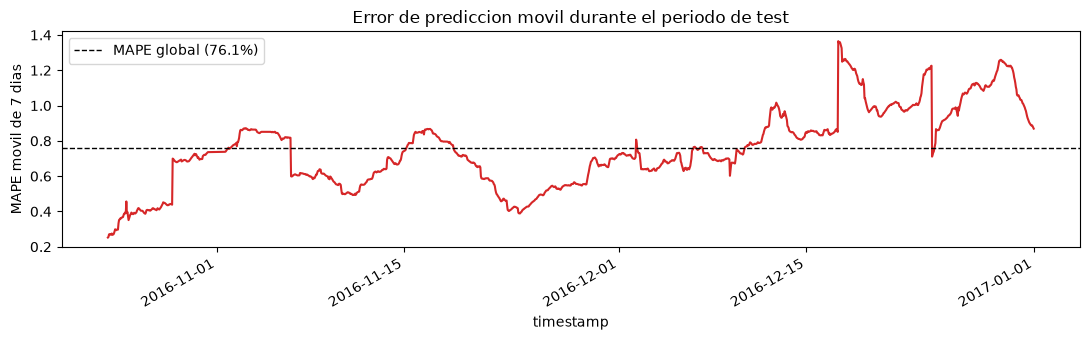

MAPE global: 76.1%, MAPE ultimos 7 dias: 86.9%, ratio: 1.14
Se marcaria 'error incrementado' segun la regla de produccion (ratio > 1.25): False


In [24]:
abs_pct_err = (comparison["actual_mw"] - comparison["predicted_mw"]).abs() / comparison["predicted_mw"].replace(0, np.nan)
overall_mape = float(abs_pct_err.mean())
recent_mape = float(abs_pct_err.tail(24 * 7).mean())  # ultima semana del periodo de test, misma ventana que usa investigate_node

fig, ax = plt.subplots(figsize=(11, 3.5))
abs_pct_err.rolling(24 * 7, min_periods=24).mean().plot(ax=ax, color="tab:red")
ax.axhline(overall_mape, color="black", ls="--", lw=1, label=f"MAPE global ({overall_mape:.1%})")
ax.set_ylabel("MAPE movil de 7 dias")
ax.set_title("Error de prediccion movil durante el periodo de test")
ax.legend()
plt.tight_layout()
plt.show()

# Mismos umbrales que usa agents/graph.py para decidir si recomendar un reentrenamiento
RECENT_ERROR_INCREASE_RATIO = 1.25   # de agents/graph.py
RETRAIN_AGE_DAYS_THRESHOLD = 90      # de agents/graph.py
error_increased = recent_mape > overall_mape * RECENT_ERROR_INCREASE_RATIO
print(f"MAPE global: {overall_mape:.1%}, MAPE ultimos 7 dias: {recent_mape:.1%}, ratio: {recent_mape/overall_mape:.2f}")
print(f"Se marcaria 'error incrementado' segun la regla de produccion (ratio > {RECENT_ERROR_INCREASE_RATIO}): {error_increased}")

### Estrategia de reentrenamiento (tal como esta implementada en `agents/graph.py`, mas recomendaciones)

**Hoy, en vivo:** `investigate_node` calcula el MAPE reciente vs. global (arriba) *y* comprueba la
antiguedad del modelo actualmente registrado via `forecasting/registry.latest_model_info`
(consulta el registro de MLflow para la marca de tiempo de registro de la ultima version). Solo
cuando **ambas** cosas ocurren - el error ha empeorado de forma medible **y** el modelo tiene mas
de 90 dias - el grafo enruta a `recommend_retrain_node` en lugar de la recomendacion normal - esto
evita disparar un reentrenamiento por cada mala semana pasajera, o reentrenar un modelo que sigue
siendo genuinamente preciso solo porque ha pasado tiempo (umbrales deliberadamente ligeros,
"a escala de demo" - ver los comentarios del archivo; los umbrales reales se ajustarian contra un
historico operativo mas largo del que da un ano de un solo parque).

**Aun no implementado, y que valdria la pena anadir a continuacion:**
- **Reentrenamiento programado** (p. ej. mensual, o cada vez que hay disponible una estacion
  completa nueva de datos) alimentando el mismo registro, de modo que el chequeo basado en
  antiguedad de arriba se apoye en una cadencia real y no solo en ejecuciones manuales.
- **Evaluacion shadow/canary** - puntuar un candidato recien entrenado contra el modelo
  actualmente en servicio sobre la misma ventana reciente *antes* de promoverlo a `latest`, para
  que un reentrenamiento no pueda empeorar las cosas silenciosamente.
- **Rollback automatico** - el registro de MLflow ya conserva cada version anterior; una mala
  promocion es una reversion de una linea (`models:/<name>/<version_anterior>`), simplemente aun
  no esta conectada a un disparador automatico.

<a id="9"></a>
## 9. Hallazgos y Accionabilidad para el Negocio

In [25]:
from IPython.display import Markdown, display

worst_cf = eff_summary["capacity_factor"].idxmin()
best_cf = eff_summary["capacity_factor"].idxmax()
worst_val, best_val = eff_summary.loc[worst_cf, "capacity_factor"], eff_summary.loc[best_cf, "capacity_factor"]
worst_flagged = flagged_hours[worst_turbine]
mean_flagged_others = np.mean([v for t, v in flagged_hours.items() if t != worst_turbine])

display(Markdown(f'''
| # | Hallazgo | Evidencia | Accion recomendada |
|---|---|---|---|
| 1 | Gradient Boosting (con la configuracion de produccion) reduce el proxy de coste por desvio en un **{reduction:.0%}** frente a un baseline ingenuo de produccion media | §5 | Confirma la propuesta de valor central del servicio de prediccion en terminos de €, no solo de MW |
| 2 | La precision del split cronologico de test (R²={results_df.loc['Gradient Boosting (config. de produccion)','r2']:.2f}) es significativamente menor que la precision de la CV k-fold (R²={np.mean(fold_r2):.2f}) | §5 | Cambiar la metrica que reporta `forecasting/train.py` a una evaluacion cronologica/`TimeSeriesSplit`, para que el numero que aparece en MLflow refleje el rendimiento real hacia adelante |
| 3 | **{worst_turbine}** tiene el menor factor de capacidad de la flota ({worst_val:.1%} vs. el mejor {best_val:.1%}) y, por mucho, mas horas de bajo rendimiento marcadas respecto a sus vecinos ({worst_flagged} vs. ~{mean_flagged_others:.0f} de media en el resto) | §6 | Priorizar la inspeccion fisica |
| 4 | ...pero el desplazamiento de la curva de potencia de ese mismo aerogenerador es de solo {displacement:+.2f} m/s - insignificante | §6 | Descarta una mala calibracion del anemometro como causa - apunta en su lugar a una causa mecanica/de estela/de paradas, lo que cambia que deberia revisar una inspeccion |
| 5 | La velocidad media del viento del SCADA del parque correlaciona {qc['correlation']:.2f} con el reanalisis independiente de Open-Meteo para las mismas horas | §6 | Saludable - sin evidencia de un problema sistemico de sensores o de alineacion de datos en la flota |
| 6 | Varias variables meteorologicas (temperatura, presion, densidad del aire) muestran un drift grande entre train/test (PSI ≥ {drift_df['psi'].iloc[0]:.2f}), pero sigue la estacionalidad conocida | §8 | No es, por si solo, una falsa alarma - pero el monitor de drift en produccion necesita una ventana de referencia que abarque un ciclo estacional completo |
'''))


| # | Hallazgo | Evidencia | Accion recomendada |
|---|---|---|---|
| 1 | Gradient Boosting (con la configuracion de produccion) reduce el proxy de coste por desvio en un **37%** frente a un baseline ingenuo de produccion media | §5 | Confirma la propuesta de valor central del servicio de prediccion en terminos de €, no solo de MW |
| 2 | La precision del split cronologico de test (R²=0.45) es significativamente menor que la precision de la CV k-fold (R²=0.76) | §5 | Cambiar la metrica que reporta `forecasting/train.py` a una evaluacion cronologica/`TimeSeriesSplit`, para que el numero que aparece en MLflow refleje el rendimiento real hacia adelante |
| 3 | **Kelmarsh_6** tiene el menor factor de capacidad de la flota (20.7% vs. el mejor 30.0%) y, por mucho, mas horas de bajo rendimiento marcadas respecto a sus vecinos (1227 vs. ~383 de media en el resto) | §6 | Priorizar la inspeccion fisica |
| 4 | ...pero el desplazamiento de la curva de potencia de ese mismo aerogenerador es de solo +0.06 m/s - insignificante | §6 | Descarta una mala calibracion del anemometro como causa - apunta en su lugar a una causa mecanica/de estela/de paradas, lo que cambia que deberia revisar una inspeccion |
| 5 | La velocidad media del viento del SCADA del parque correlaciona 0.90 con el reanalisis independiente de Open-Meteo para las mismas horas | §6 | Saludable - sin evidencia de un problema sistemico de sensores o de alineacion de datos en la flota |
| 6 | Varias variables meteorologicas (temperatura, presion, densidad del aire) muestran un drift grande entre train/test (PSI ≥ 2.15), pero sigue la estacionalidad conocida | §8 | No es, por si solo, una falsa alarma - pero el monitor de drift en produccion necesita una ventana de referencia que abarque un ciclo estacional completo |


### Que significa esto para el negocio
Un operador de parques eolicos que use este sistema obtiene: (a) una prediccion de produccion
sustancialmente mejor que una planificacion ingenua, que se traduce directamente en menor
exposicion por liquidacion de desvios; (b) una prioridad de mantenimiento concreta y ordenada (un
aerogenerador concreto, no "el parque rindio mal de alguna manera") con un primer diagnostico de
*por que* (mecanico vs. de sensor) que cambia que deberia revisar un tecnico; y (c) una senal
automatizada de *cuando* el propio modelo de prediccion necesita atencion, en lugar de depender de
que alguien note que la precision se degrada silenciosamente.

<a id="10"></a>
## 10. Conclusion

Este notebook recorrio el ciclo de vida completo de extremo a extremo sobre datos reales:
planteamiento del problema ligado a una metrica de negocio concreta, exploracion y un chequeo real
de calidad de datos, ingenieria de variables reutilizada directamente de la base de codigo de
produccion, una comparacion rigurosa desde los baselines hasta el modelo de produccion (incluyendo
una critica honesta de la propia metodologia de evaluacion), diagnosticos fisicos/operacionales
mas alla de la prediccion, y una estrategia de monitorizacion/reentrenamiento que ya corre
parcialmente en el agente en vivo detras de
[windward.forwardforecasting.eu](https://windward.forwardforecasting.eu/).

**Proximos pasos que priorizaria con mas tiempo:** evaluacion cronologica/`TimeSeriesSplit` en el
propio `forecasting/train.py` (hallazgo #2 del §5); reentrenamiento programado + evaluacion shadow
(§8); y extender este mismo notebook a los otros dos parques registrados para comprobar si el
resultado de la comparacion de modelos (§4 - los tres modelos entrenados quedando muy cerca entre
si) se mantiene en general o es especifico del perfil de aerogenerador/terreno de Kelmarsh.